In [1]:
from Node import Node
import torch
import faiss
import os
import pickle
from LLM.qwen3_vl_embedding import Qwen3VLEmbedder
from PIL import Image
import matplotlib.pyplot as plt

#file_paths
DIR_PATH = "2-Build_Graph"
BASE_PATH = ""
g4_path = "2-Build_Graph/data/g4.pkl"
faiss_path = os.path.join(DIR_PATH, "data", "embeddings_hnsw.faiss")
embedding_processed_ids_path = f"{DIR_PATH}/data/embedding_processed_ids.txt"

with open(embedding_processed_ids_path, "r", encoding="utf-8") as f:
    embedding_processed_ids_list = [line.strip() for line in f if line.strip()]

index = faiss.read_index(faiss_path)

#load new data to embed

with open(g4_path, "rb") as f:
    nodes = pickle.load(f)
for node in nodes.values():
    if node.node_type in ["S", "A", "T", "V", "H"]:
        if node.node_id not in embedding_processed_ids_list:
            print(node.node_id)

c:\Users\HP\Desktop\Projects\MMNodeRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
model = Qwen3VLEmbedder(model_name_or_path="Qwen/Qwen3-VL-Embedding-2B")

Using device: cuda


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 1344.70it/s]


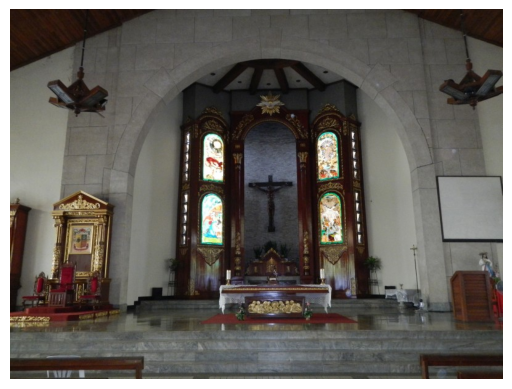

In [7]:
def format_query(q = None, img = None):
    return [{"text": q, "image": img, "instruction": "Retrieve images or text relevant to the user's query.",}]
query = "What is the architectural style of this building?"
img = "InfoSeek/oven_images_sampled/oven_05012596.jpg"
query_embedding = model.process(format_query(query,img)).to(torch.float32).cpu().numpy()

img = Image.open(img)
plt.imshow(img)
plt.axis("off")
plt.show()

The Saint Dominic Cathedral, also known as the Bayombong Cathedral, is an 18th-century Baroque church located in Brgy. Salvacion, Bayombong, Nueva Vizcaya, Philippines. It serves as the seat of the Roman Catholic Diocese of Bayombong and is under the patronage of Saint Dominic.
Rank: 0
0.52391946
------------------------------


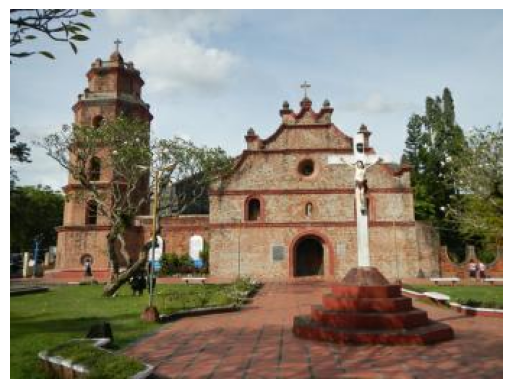

Rank: 1
0.5134198
------------------------------
The Saint Dominic Cathedral, commonly referred to as the Bayombong Cathedral, is an 18th-century, Baroque church located at Brgy. Salvacion, Bayombong, Nueva Vizcaya, Philippines. The cathedral, which is the seat of the Roman Catholic Diocese of Bayombong, is under the patronage of Saint Dominic. Saint Dominic Cathedral of Bayombong, Nueva Vizcaya, Philippines was founded in 1739 by the Augustinian Friars of Spain. ## Church history. It was April 12, 1739 when the first Eucharistic Celebration was held there with Fray Pedro Freire presiding. During these days in the 18th century, this cathedral was still called The Church of St. Augustine. It won’t be until a few months later, on September 8, that it will be dedicated to St. Dominic De Guzman. The mission in present-day Bayombong had its roots in the mid-18th century when it was formally accepted by the Dominicans as mission center in a region previously referred to as Paniqui. Soon afte

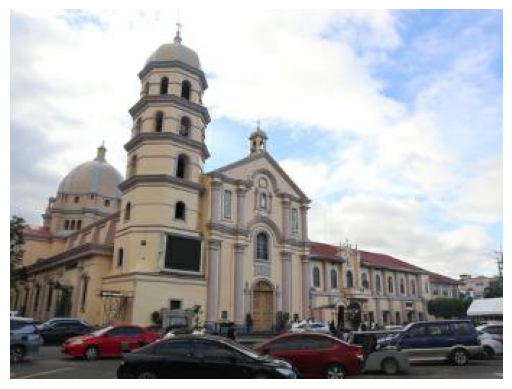

Rank: 8
0.47089773
------------------------------
The Shrine of Mary, Queen of Peace, also known as the EDSA Shrine, is a small Roman Catholic church located at the intersection of Ortigas Avenue and Epifanio de los Santos Avenue (EDSA) in Barangay Ugong Norte, Quezon City. It is part of the Roman Catholic Archdiocese of Manila and is also referred to as the Archdiocesan Shrine of Mary, Queen of Peace or Mary, Queen of Peace Quasi-Parish, though these names are rarely used. The National Commission for Culture and the Arts has declared it an Important Cultural Property.
Rank: 9
0.4688555
------------------------------
The Saint Dominic Cathedral of Bayombong, Nueva Vizcaya, Philippines was founded in 1739 by the Augustinian Friars of Spain.
Rank: 10
0.46829137
------------------------------
Our Lady of Peace, "Mother of Peace", "Queen of Peace" or "Our Lady Queen of Peace" is a title of the Blessed Virgin Mary in the Catholic Church. She is represented in art holding a dove and an olive

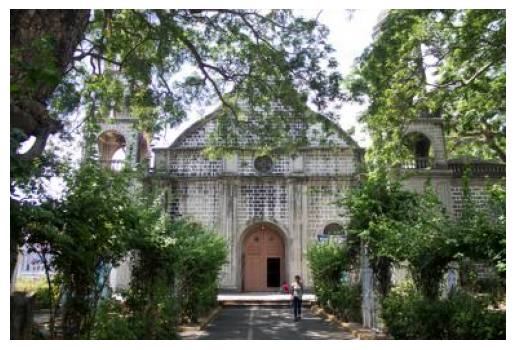

Rank: 17
0.4427178
------------------------------
The first stone church was built as a basilica in Romanesque style, featuring a nave, two aisles, a western tower, a transept, a square chancel, and an apse-like east end, with the possibility that the transept arms also had apses.
Rank: 18
0.4410388
------------------------------
The entity is identified as the Roman Catholic Parish Church of Saint John the Baptist in the City of Calamba, with an Official Facebook page.
Rank: 19
0.43751508
------------------------------
Architect Mañosa envisioned a design for the EDSA Shrine, dubbing it the "People's Basilica," which was derived from the concept of the bahay kubo on a larger scale and initially called for seven pitched roofs framing a statue of the Virgin Mary.
Rank: 20
0.43271887
------------------------------
The term "church" refers to Christian religious institutions and their associated buildings, which serve as central components of cultural-historical heritage across Europe, th

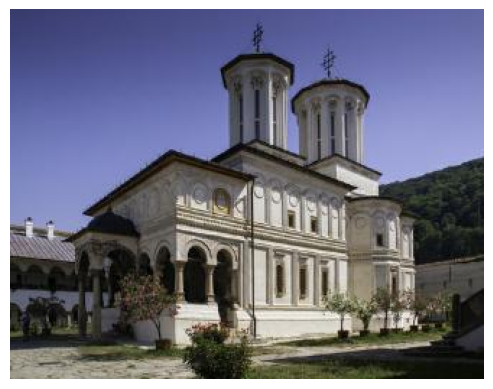

Rank: 24
0.41742045
------------------------------
The structure features a palace architectural style characterized by barrel vaulting and a long columned porch, with a roof section that resembles a boat.
Rank: 25
0.41668344
------------------------------
The façade of the Saint Dominic Cathedral is described as a close copy of the San Vicente Ferrer Church in Dupax del Sur and the Santa Catalina de Siena Church in Bambang, Nueva Vizcaya. Its doors, windows, oculus, and pediment shape are similar to those of the older Tuguegarao Cathedral in Cagayan province. A difference between the Saint Dominic Cathedral and the other two churches is the lack of columns framing the windows.
Rank: 26
0.4166
------------------------------


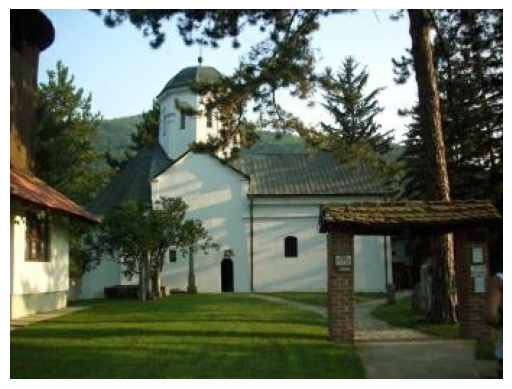

Rank: 27
0.4163738
------------------------------
The term Triumphal arch is also the name given to the arch above the entrance to the chancel of a medieval church where a rood can be placed.
Rank: 28
0.4120043
------------------------------
The main altarpiece of the structure is a Gothic revival piece from 1905, and the furnishings date from several centuries.
Rank: 29
0.41184285
------------------------------
The interior of the Shrine contains the Sanctuary, a high vaulted space entered by four tall portals of Classical design.
Rank: 30
0.40829614
------------------------------
The so-called bridal portal is in a typically late Romanesque Rhenish style, representing a feature of the medieval church.
Rank: 31
0.4000438
------------------------------


In [8]:
k = 32
D, I = index.search(query_embedding, k)
for i in range(k):
    id = embedding_processed_ids_list[I[0][i]]
    if "H" in id:
        continue
    node = nodes[id]

    content = node.content
    if node.node_type != "V":
        print(content)
    else:
        img = Image.open(content)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    print(f"Rank: {i}")
    print(D[0][i])
    print("-"*30)